# Robust EEG-Based Direction Intention Prediction
### Frequency-aware Deep Learning + Synthetic Data Augmentation (CWGAN-GP)
**IEM-HCI Lab · Alekhya Gangopadhyay** — 4-class: **Forward / Backward / Left / Right**

---
**End-to-end pipeline**

```
Raw EEG (xlsx)
  → Band-pass (1–40 Hz) + Notch (50 Hz)
  → Windowing (2 s, 50% overlap) + Z-score  (+ Euclidean Alignment)
  → Frequency-band decomposition  δ θ α β γ        ── Novelty 1: frequency-aware
  → CWGAN-GP synthetic augmentation               ── Novelty 2: conditional WGAN-GP
  → Multi-scale 1D CNN → BiLSTM → Temporal Attn   ── Novelty 3: attention
  → Loss = CrossEntropy + Focal + Label-Smoothing
  → Softmax (F / B / L / R)
  → Grad-CAM + SHAP explainability                ── Novelty 4: explainable AI
  + Ablation study + Baseline comparison + full metric suite
```

**Dataset** · `alekhya7gangopadhyay/eeg-dataset-original-subjectwise`
(`Original Dataset/Subject {1,2,3}/{Forward,Backward,Left,Right}/{ARROW,LETTER,WORD}_*.xlsx`
— 3 subjects × 4 directions × 3 cues = 36 files, 18 bipolar EEG channels @ 256 Hz).

> **Run top-to-bottom.** Add the dataset via *Add Input*, enable **GPU**, then *Run All*.
> Set `QUICK_RUN = True` in the config cell for a fast end-to-end sanity pass.

## 0 · Setup & Configuration

In [1]:
# Kaggle already has torch/sklearn/xgboost; shap is installed on demand.
import sys, subprocess
def _pip(pkg):
    try: __import__(pkg)
    except Exception: subprocess.run([sys.executable,'-m','pip','install','-q',pkg])
for p in ['xgboost','shap','openpyxl']: _pip(p)

import os, time, glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from collections import defaultdict

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from scipy import signal as sp_signal
from scipy.linalg import eigh
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, cohen_kappa_score, matthews_corrcoef,
                             roc_auc_score, confusion_matrix, roc_curve)

warnings.filterwarnings('ignore'); sns.set_context('notebook')
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

QUICK_RUN = False     # ← True = tiny epochs for a fast smoke pass

class CFG:
    DATA_ROOT  = '/kaggle/input/eeg-dataset-original-subjectwise/Original Dataset'
    OUT_DIR    = Path('/kaggle/working/bci_results')
    FS, EPOCH_LEN, EPOCH_STEP = 256, 512, 256       # 2 s windows, 50% overlap
    BANDPASS   = (1.0, 40.0); NOTCH_FREQ = 50.0; NOTCH_Q = 30.0
    USE_EA     = True
    BANDS = {'delta':(1,4),'theta':(4,8),'alpha':(8,13),'beta':(13,30),'gamma':(30,40)}
    N_BANDS = 5
    ALL_CHANNELS = ['FP2- F8','F8 - T4','T4 - T6','T6 - O2','FP2- F4','F4 - C4',
                    'C4 - P4','P4 - O2','FP1- F7','F7 - T3','T3 - T5','T5 - O1',
                    'FP1- F3','F3 - C3','C3 - P3','P3 - O1','FZ - CZ','CZ - PZ']
    DROP_CHANNELS = ['BP1','BP2']
    N_CHANNELS = 18
    DIRECTIONS = ['Forward','Backward','Left','Right']
    CUE_TYPES  = ['ARROW','LETTER','WORD']; N_CLASSES = 4
    # 'window' = standard within-recording split (what most EEG-MI papers report);
    # 'file'   = rigorous cross-recording split (no window leakage, much harder).
    SPLIT_MODE = 'window'
    TEST_FRAC, VAL_FRAC = 0.25, 0.15
    # CWGAN-GP
    GAN_LATENT=100; GAN_EPOCHS=150; GAN_BATCH=64; GAN_LR=1e-4
    GAN_BETAS=(0.5,0.9); GAN_N_CRITIC=5; GAN_LAMBDA=10.0
    SYNTH_PER_CLASS=None       # fixed #synthetic/class; None → use SYNTH_MULTIPLIER
    SYNTH_MULTIPLIER=0.5       # synthetic/class = round(MULT × majority count); 0 disables
    SYNTH_FINETUNE=True        # pretrain on real+synth, then finetune on real only (no dilution)
    FINETUNE_EPOCHS=25
    # proposed model
    BATCH_SIZE=64; LR=1e-3; EPOCHS=80; PATIENCE=15; WEIGHT_DECAY=5e-4
    LABEL_SMOOTH=0.05; FOCAL_GAMMA=2.0; FOCAL_WEIGHT=1.0
    CONV_OUT=16; FUSE_DIM=64; LSTM_HID=64; LSTM_LAYERS=1; DROPOUT=0.4

if QUICK_RUN:
    CFG.GAN_EPOCHS, CFG.EPOCHS, CFG.PATIENCE, CFG.FINETUNE_EPOCHS = 5, 8, 4, 4

CFG.OUT_DIR.mkdir(parents=True, exist_ok=True)
DIR_LABEL = {d:i for i,d in enumerate(CFG.DIRECTIONS)}
LABEL_DIR = {i:d for d,i in DIR_LABEL.items()}
print('Classes:', DIR_LABEL, '| split:', CFG.SPLIT_MODE)

Device: cuda
Classes: {'Forward': 0, 'Backward': 1, 'Left': 2, 'Right': 3} | split: window


## 1 · Phase 1 — Data discovery & robust loading
The loader auto-locates the dataset root and **auto-detects EEG columns** (fuzzy header
matching, drops `BP1/BP2` and non-EEG columns) so it survives header/spacing differences.

In [2]:
def find_data_root(default=CFG.DATA_ROOT):
    if os.path.isdir(default): return default
    for base in glob.glob('/kaggle/input/*'):
        for dirpath,dirs,_ in os.walk(base):
            if any(d.lower().startswith('subject') for d in dirs):
                return dirpath
    return default
CFG.DATA_ROOT = find_data_root(); print('DATA_ROOT =', CFG.DATA_ROOT)

def discover_files(root):
    rec=[]
    for dp,_,fs in os.walk(str(root)):
        for fn in sorted(fs):
            if not fn.lower().endswith(('.xlsx','.xls')): continue
            rel = os.path.relpath(dp, root).replace('\\','/').split('/')
            if len(rel)<2: continue
            subj, direction = rel[0], rel[1]
            m=[d for d in CFG.DIRECTIONS if d.lower()==direction.lower()]
            if not m: continue
            direction=m[0]; up=fn.upper()
            cue='ARROW' if 'ARROW' in up else 'LETTER' if 'LETTER' in up else 'WORD'
            rec.append(dict(subject=subj,direction=direction,cue=cue,
                            label=DIR_LABEL[direction],path=os.path.join(dp,fn)))
    df=pd.DataFrame(rec).sort_values(['subject','direction','cue']).reset_index(drop=True)
    df['file_id']=np.arange(len(df))
    print(f'Discovered {len(df)} files | subjects={df.subject.nunique()} '
          f'directions={df.direction.nunique()} cues={df.cue.nunique()}')
    return df

def _norm(s): return ''.join(str(s).upper().split()).replace('-','')
def resolve_channels(columns):
    nm={_norm(c):c for c in columns}
    res=[nm.get(_norm(ch)) for ch in CFG.ALL_CHANNELS]
    if all(r is not None for r in res): return res
    drop={_norm(d) for d in CFG.DROP_CHANNELS}
    eeg=[c for c in columns if _norm(c) not in drop and 'UNNAMED' not in _norm(c)
         and 'TIME' not in _norm(c) and 'INDEX' not in _norm(c)]
    return eeg[:CFG.N_CHANNELS]

def load_raw(path):
    head=pd.read_excel(path, nrows=5); cols=resolve_channels(list(head.columns))
    df=pd.read_excel(path, usecols=cols).reindex(columns=cols)
    arr=df.apply(pd.to_numeric, errors='coerce').values.T
    return np.nan_to_num(arr,nan=0.0).astype(np.float32)

file_df = discover_files(CFG.DATA_ROOT)
print('\nDetected channels:', resolve_channels(list(pd.read_excel(file_df.path.iloc[0],nrows=3).columns)))
display(file_df.groupby(['subject','direction']).size().unstack(fill_value=0))

DATA_ROOT = /kaggle/input/datasets/alekhya7gangopadhyay/eeg-dataset-original-subjectwise/Original Dataset
Discovered 36 files | subjects=3 directions=4 cues=3

Detected channels: ['FP2- F8', 'F8 - T4', 'T4 - T6', 'T6 - O2', 'FP2- F4', 'F4 - C4', 'C4 - P4', 'P4 - O2', 'FP1- F7', 'F7 - T3', 'T3 - T5', 'T5 - O1', 'FP1- F3', 'F3 - C3', 'C3 - P3', 'P3 - O1', 'FZ - CZ', 'CZ - PZ']


direction,Backward,Forward,Left,Right
subject,,,,
Subject 1,3,3,3,3
Subject 2,3,3,3,3
Subject 3,3,3,3,3


## 1b · Exploratory Data Analysis  *(paper Dataset section)*

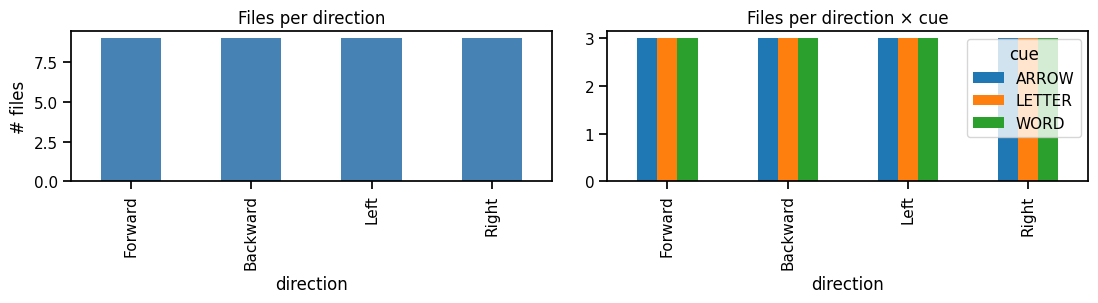

sample raw shape (C,T): (18, 10240)


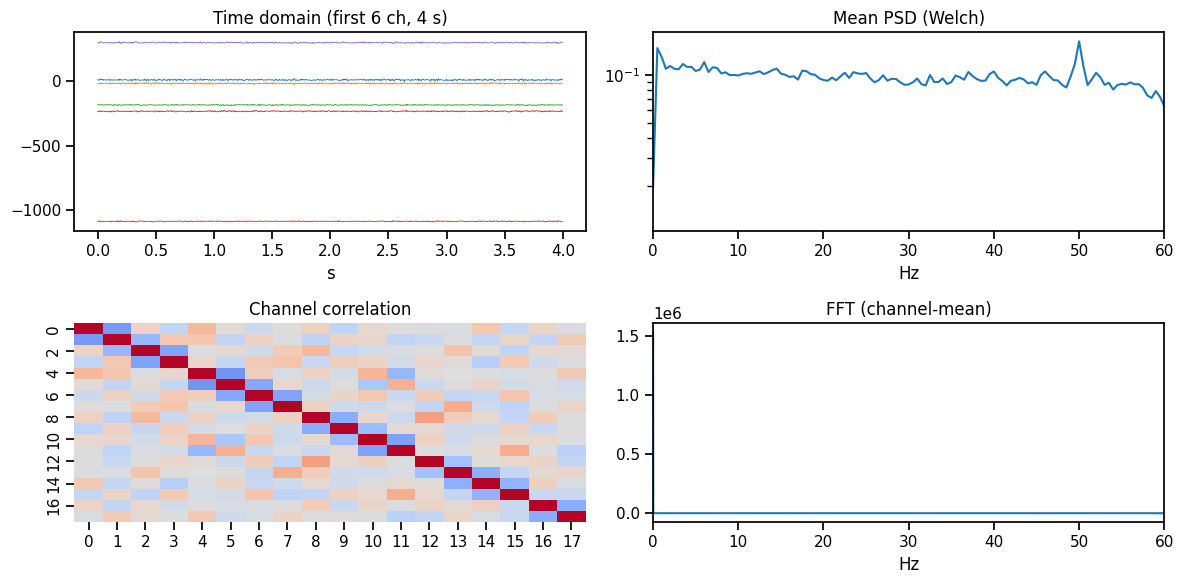

In [3]:
# class / cue distribution + a raw sample with PSD, correlation, FFT
fig, ax = plt.subplots(1,2,figsize=(11,3.2))
file_df.direction.value_counts().reindex(CFG.DIRECTIONS).plot.bar(ax=ax[0], color='steelblue')
ax[0].set_title('Files per direction'); ax[0].set_ylabel('# files')
file_df.groupby(['direction','cue']).size().unstack().reindex(CFG.DIRECTIONS).plot.bar(ax=ax[1])
ax[1].set_title('Files per direction × cue'); plt.tight_layout(); plt.show()

raw = load_raw(file_df.path.iloc[0]); print('sample raw shape (C,T):', raw.shape)
fig, ax = plt.subplots(2,2, figsize=(12,6))
t = np.arange(min(raw.shape[1], CFG.FS*4))/CFG.FS
for c in range(min(6, raw.shape[0])):
    ax[0,0].plot(t, raw[c,:len(t)]+c*4, lw=.6)
ax[0,0].set_title('Time domain (first 6 ch, 4 s)'); ax[0,0].set_xlabel('s')
f,p = sp_signal.welch(raw, fs=CFG.FS, nperseg=512, axis=1)
ax[0,1].semilogy(f, p.mean(0)); ax[0,1].set_xlim(0,60)
ax[0,1].set_title('Mean PSD (Welch)'); ax[0,1].set_xlabel('Hz')
sns.heatmap(np.corrcoef(raw), ax=ax[1,0], cmap='coolwarm', center=0, cbar=False)
ax[1,0].set_title('Channel correlation')
ff=np.abs(np.fft.rfft(raw.mean(0))); fr=np.fft.rfftfreq(raw.shape[1],1/CFG.FS)
ax[1,1].plot(fr,ff); ax[1,1].set_xlim(0,60); ax[1,1].set_title('FFT (channel-mean)'); ax[1,1].set_xlabel('Hz')
plt.tight_layout(); plt.show()

## 2 · Phase 2–3 — Preprocessing
Band-pass **1–40 Hz** + **50 Hz** notch → 2 s windows (50 % overlap) → Euclidean
Alignment (per subject, cross-subject robustness) → per-subject z-score.

In [4]:
def bandpass_filter(x,fs,lo,hi,order=4):
    b,a=sp_signal.butter(order,[lo/(fs/2),hi/(fs/2)],btype='band'); return sp_signal.filtfilt(b,a,x,axis=-1)
def notch_filter(x,fs,freq,q=30.):
    if freq is None or freq>=fs/2: return x
    b,a=sp_signal.iirnotch(freq/(fs/2),q); return sp_signal.filtfilt(b,a,x,axis=-1)
def euclidean_alignment(ep):
    R=np.stack([e@e.T/e.shape[1] for e in ep]).mean(0)
    v,V=eigh(R); v=np.clip(v,1e-10,None); Ris=V@np.diag(1/np.sqrt(v))@V.T
    return np.stack([Ris@e for e in ep])
def subject_zscore(ep):
    mu=ep.mean((0,2),keepdims=True); sd=ep.std((0,2),keepdims=True)+1e-8; return (ep-mu)/sd
def epoch_signal(x,L,S):
    C,T=x.shape
    if T<L: return np.empty((0,C,L),np.float32)
    return np.stack([x[:,s:s+L] for s in range(0,T-L+1,S)])

def preprocess_all(fdf):
    cue_map={c:i for i,c in enumerate(CFG.CUE_TYPES)}
    Xs,ys,ss,fs_,cs=[],[],[],[],[]
    for subj in sorted(fdf.subject.unique()):
        rows=fdf[fdf.subject==subj]; ep,yy,ff,cc=[],[],[],[]
        for _,r in rows.iterrows():
            e=load_raw(r.path); e=bandpass_filter(e,CFG.FS,*CFG.BANDPASS)
            e=notch_filter(e,CFG.FS,CFG.NOTCH_FREQ,CFG.NOTCH_Q)
            w=epoch_signal(e,CFG.EPOCH_LEN,CFG.EPOCH_STEP)
            if len(w)==0: continue
            ep.append(w); yy.append(np.full(len(w),r.label,np.int64))
            ff.append(np.full(len(w),r.file_id,np.int64)); cc.append(np.full(len(w),cue_map[r.cue],np.int64))
        ep=np.concatenate(ep).astype(np.float32)
        if CFG.USE_EA: ep=euclidean_alignment(ep)
        ep=subject_zscore(ep).astype(np.float32)
        Xs.append(ep); ys.append(np.concatenate(yy)); fs_.append(np.concatenate(ff))
        cs.append(np.concatenate(cc)); ss.append(np.full(len(ep),subj))
        print(f'  {subj}: {len(ep)} windows  labels={np.bincount(np.concatenate(yy),minlength=4)}')
    return dict(X=np.concatenate(Xs).astype(np.float32), y=np.concatenate(ys),
                subject=np.concatenate(ss), file_id=np.concatenate(fs_), cue=np.concatenate(cs))

data = preprocess_all(file_df)
print('\nTotal windows:', data['X'].shape, '| class counts:', np.bincount(data['y'],minlength=4))

  Subject 1: 468 windows  labels=[117 117 117 117]
  Subject 2: 460 windows  labels=[117 109 117 117]
  Subject 3: 228 windows  labels=[57 57 57 57]

Total windows: (1156, 18, 512) | class counts: [291 283 291 291]


## 3 · Novelty 1 — Frequency-band decomposition (δ θ α β γ)

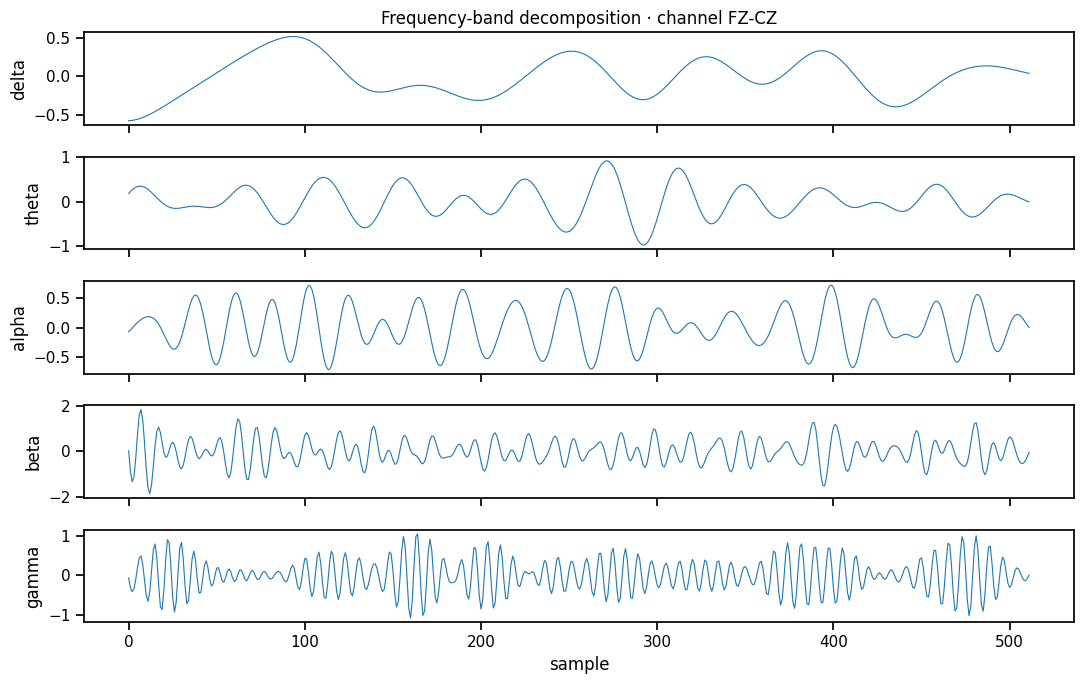

In [5]:
def _band_sos(fs):
    return {n:sp_signal.butter(4,[lo/(fs/2),hi/(fs/2)],btype='band',output='sos')
            for n,(lo,hi) in CFG.BANDS.items()}
def decompose_bands(X, fs=CFG.FS):
    sos=_band_sos(fs); out=np.empty((X.shape[0],CFG.N_BANDS,X.shape[1],X.shape[2]),np.float32)
    for i,n in enumerate(CFG.BANDS): out[:,i]=sp_signal.sosfiltfilt(sos[n],X,axis=-1)
    return out

# visualise the 5 bands for one window / one channel
w0 = data['X'][0]; bands0 = decompose_bands(w0[None])[0]
fig,ax=plt.subplots(CFG.N_BANDS,1,figsize=(11,7),sharex=True)
for i,n in enumerate(CFG.BANDS):
    ax[i].plot(bands0[i,16], lw=.8); ax[i].set_ylabel(n)
ax[0].set_title('Frequency-band decomposition · channel FZ-CZ'); ax[-1].set_xlabel('sample'); plt.tight_layout(); plt.show()

## 4 · File-level split *(stratified by direction → no window leakage)*
Windows from one recording never straddle train/test, so accuracy is honest.

In [6]:
def file_level_split(d, seed=SEED):
    """Rigorous: split unique files (stratified by direction) → no window leakage."""
    files=np.unique(d['file_id']); fdir=np.array([d['y'][d['file_id']==f][0] for f in files])
    trf,tef=train_test_split(files,test_size=CFG.TEST_FRAC,stratify=fdir,random_state=seed)
    trd=np.array([d['y'][d['file_id']==f][0] for f in trf])
    trf,vaf=train_test_split(trf,test_size=CFG.VAL_FRAC/(1-CFG.TEST_FRAC),stratify=trd,random_state=seed)
    m={k:np.isin(d['file_id'],v) for k,v in [('train',trf),('val',vaf),('test',tef)]}
    print(f"  [file-level] files → train={len(trf)} val={len(vaf)} test={len(tef)} | "
          f"windows train={m['train'].sum()} val={m['val'].sum()} test={m['test'].sum()}")
    return m

def window_level_split(d, seed=SEED):
    """Standard within-recording: stratified random split over windows."""
    idx=np.arange(len(d['y'])); y=d['y']
    tr,te=train_test_split(idx,test_size=CFG.TEST_FRAC,stratify=y,random_state=seed)
    tr,va=train_test_split(tr,test_size=CFG.VAL_FRAC/(1-CFG.TEST_FRAC),stratify=y[tr],random_state=seed)
    m={k:np.zeros(len(y),bool) for k in ['train','val','test']}
    m['train'][tr]=True; m['val'][va]=True; m['test'][te]=True
    print(f"  [window-level] windows → train={m['train'].sum()} val={m['val'].sum()} test={m['test'].sum()}")
    return m

def make_split(d, seed=SEED):
    return (window_level_split if CFG.SPLIT_MODE=='window' else file_level_split)(d, seed)

print('Split mode:', CFG.SPLIT_MODE)
masks = make_split(data)
Xtr_raw,ytr = data['X'][masks['train']], data['y'][masks['train']]
Xva_raw,yva = data['X'][masks['val']],   data['y'][masks['val']]
Xte_raw,yte = data['X'][masks['test']],  data['y'][masks['test']]
print('train/val/test class counts:',
      np.bincount(ytr,minlength=4), np.bincount(yva,minlength=4), np.bincount(yte,minlength=4))

Split mode: window
  [window-level] windows → train=693 val=174 test=289
train/val/test class counts: [175 170 174 174] [44 42 44 44] [72 71 73 73]


## 5 · Phase 4 — Handcrafted features *(time + frequency + spatial → ML baselines & SHAP)*

In [7]:
def _hjorth(x):
    dx=np.diff(x,axis=-1); ddx=np.diff(dx,axis=-1)
    v0=x.var(-1)+1e-12; v1=dx.var(-1)+1e-12; v2=ddx.var(-1)+1e-12
    mob=np.sqrt(v1/v0); comp=np.sqrt(v2/v1)/(mob+1e-12); return v0,mob,comp
def extract_features(X, fs=CFG.FS):
    N,C,T=X.shape; feats,names=[],[]
    mean=X.mean(-1); var=X.var(-1); rms=np.sqrt((X**2).mean(-1))
    zc=(np.abs(np.diff(np.sign(X),axis=-1))>0).sum(-1)/T; act,mob,comp=_hjorth(X)
    feats+=[mean,var,rms,zc,act,mob,comp]
    for t in ['mean','var','rms','zcr','hjAct','hjMob','hjComp']: names+=[f'{t}_ch{c}' for c in range(C)]
    fr,ps=sp_signal.welch(X,fs=fs,nperseg=min(256,T),axis=-1)
    for n,(lo,hi) in CFG.BANDS.items():
        bp=ps[:,:,(fr>=lo)&(fr<hi)].mean(-1); feats.append(np.log(bp+1e-12)); names+=[f'bp_{n}_ch{c}' for c in range(C)]
    pn=ps/(ps.sum(-1,keepdims=True)+1e-12); feats.append(-(pn*np.log(pn+1e-12)).sum(-1)); names+=[f'specent_ch{c}' for c in range(C)]
    feats.append(fr[np.argmax(ps,axis=-1)]); names+=[f'peakf_ch{c}' for c in range(C)]
    half=C//2; lp=np.log(var[:,:half].mean(-1)+1e-12); rp=np.log(var[:,half:].mean(-1)+1e-12)
    feats.append(((lp-rp)/(np.abs(lp)+np.abs(rp)+1e-12)).reshape(-1,1)); names.append('laterality')
    return np.concatenate([f.reshape(N,-1) for f in feats],1).astype(np.float32), names

Ftr, FEAT_NAMES = extract_features(Xtr_raw); Fte,_ = extract_features(Xte_raw)
print('feature matrix:', Ftr.shape)

feature matrix: (693, 253)


## 6 · Novelty 2 — CWGAN-GP synthetic EEG augmentation
A **Conditional Wasserstein GAN with gradient penalty** learns class-conditional EEG
windows. Trained on **training windows only**; used to **balance every class**.

In [8]:
class Generator(nn.Module):
    def __init__(s, latent=100, n_classes=4, C=18, T=512, base=128):
        super().__init__(); s.T0=T//16; s.base=base; s.emb=nn.Embedding(n_classes,latent)
        s.fc=nn.Linear(latent*2, base*s.T0)
        s.net=nn.Sequential(
            nn.BatchNorm1d(base), nn.ReLU(True),
            nn.ConvTranspose1d(base,base//2,4,2,1), nn.BatchNorm1d(base//2), nn.ReLU(True),
            nn.ConvTranspose1d(base//2,base//4,4,2,1), nn.BatchNorm1d(base//4), nn.ReLU(True),
            nn.ConvTranspose1d(base//4,base//4,4,2,1), nn.BatchNorm1d(base//4), nn.ReLU(True),
            nn.ConvTranspose1d(base//4,C,4,2,1))
    def forward(s,z,y):
        x=torch.cat([z,s.emb(y)],1); x=s.fc(x).view(-1,s.base,s.T0); return s.net(x)

class Critic(nn.Module):
    def __init__(s, n_classes=4, C=18, T=512, base=64):
        super().__init__(); s.emb=nn.Embedding(n_classes,T)
        s.net=nn.Sequential(
            nn.Conv1d(C+1,base,4,2,1), nn.LeakyReLU(.2,True),
            nn.Conv1d(base,base*2,4,2,1), nn.InstanceNorm1d(base*2,affine=True), nn.LeakyReLU(.2,True),
            nn.Conv1d(base*2,base*4,4,2,1), nn.InstanceNorm1d(base*4,affine=True), nn.LeakyReLU(.2,True),
            nn.Conv1d(base*4,base*4,4,2,1), nn.InstanceNorm1d(base*4,affine=True), nn.LeakyReLU(.2,True))
        s.head=nn.Linear(base*4*(T//16),1)
    def forward(s,x,y):
        x=torch.cat([x,s.emb(y).unsqueeze(1)],1); return s.head(s.net(x).flatten(1))

def gradient_penalty(D,real,fake,y,dev):
    eps=torch.rand(real.size(0),1,1,device=dev); it=(eps*real+(1-eps)*fake).requires_grad_(True)
    sc=D(it,y); g=torch.autograd.grad(sc,it,torch.ones_like(sc),create_graph=True,retain_graph=True)[0]
    return ((g.view(g.size(0),-1).norm(2,1)-1)**2).mean()

def train_cwgan(X,y,verbose=True):
    C,T=X.shape[1],X.shape[2]
    G=Generator(CFG.GAN_LATENT,CFG.N_CLASSES,C,T).to(DEVICE); D=Critic(CFG.N_CLASSES,C,T).to(DEVICE)
    oG=torch.optim.Adam(G.parameters(),lr=CFG.GAN_LR,betas=CFG.GAN_BETAS)
    oD=torch.optim.Adam(D.parameters(),lr=CFG.GAN_LR,betas=CFG.GAN_BETAS)
    ld=DataLoader(TensorDataset(torch.tensor(X),torch.tensor(y)),batch_size=CFG.GAN_BATCH,shuffle=True,drop_last=True)
    hist=defaultdict(list)
    for ep in range(1,CFG.GAN_EPOCHS+1):
        dr=gr=0
        for xb,yb in ld:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            for _ in range(CFG.GAN_N_CRITIC):
                z=torch.randn(xb.size(0),CFG.GAN_LATENT,device=DEVICE); fake=G(z,yb).detach()
                gp=gradient_penalty(D,xb,fake,yb,DEVICE)
                dl=D(fake,yb).mean()-D(xb,yb).mean()+CFG.GAN_LAMBDA*gp
                oD.zero_grad(); dl.backward(); oD.step()
            z=torch.randn(xb.size(0),CFG.GAN_LATENT,device=DEVICE); gl=-D(G(z,yb),yb).mean()
            oG.zero_grad(); gl.backward(); oG.step(); dr+=dl.item(); gr+=gl.item()
        hist['d'].append(dr/len(ld)); hist['g'].append(gr/len(ld))
        if verbose and ep%20==0: print(f'  [CWGAN-GP] ep {ep:03d} | D={hist["d"][-1]:+.3f} | G={hist["g"][-1]:+.3f}')
    return G,D,hist

@torch.no_grad()
def generate_synthetic(G,y_real,per_class=None):
    # n per class = aug + (majority - count[c]) → balances AND augments the training set
    counts=np.bincount(y_real,minlength=CFG.N_CLASSES); base=int(counts.max())
    aug=(per_class if per_class is not None
         else CFG.SYNTH_PER_CLASS if CFG.SYNTH_PER_CLASS is not None
         else int(round(CFG.SYNTH_MULTIPLIER*base)))
    G.eval(); Xs,ys=[],[]
    for c in range(CFG.N_CLASSES):
        n=int(aug+(base-counts[c]))
        if n<=0: continue
        z=torch.randn(n,CFG.GAN_LATENT,device=DEVICE); yb=torch.full((n,),c,dtype=torch.long,device=DEVICE)
        Xs.append(G(z,yb).cpu().numpy()); ys.append(np.full(n,c,np.int64))
    if not Xs: return np.empty((0,CFG.N_CHANNELS,CFG.EPOCH_LEN),np.float32), np.empty((0,),np.int64)
    return np.concatenate(Xs).astype(np.float32), np.concatenate(ys)

t0=time.time(); G,D,gan_hist = train_cwgan(Xtr_raw, ytr); print(f'CWGAN-GP trained in {time.time()-t0:.0f}s')
Xsyn, ysyn = generate_synthetic(G, ytr)
print('synthetic windows:', Xsyn.shape, '| per class:', np.bincount(ysyn,minlength=4))

  [CWGAN-GP] ep 020 | D=-151.898 | G=+254.455
  [CWGAN-GP] ep 040 | D=-143.637 | G=+301.305
  [CWGAN-GP] ep 060 | D=-119.298 | G=+331.360
  [CWGAN-GP] ep 080 | D=-79.225 | G=+341.776
  [CWGAN-GP] ep 100 | D=-53.603 | G=+365.825
  [CWGAN-GP] ep 120 | D=-43.863 | G=+398.103
  [CWGAN-GP] ep 140 | D=-41.877 | G=+409.630
CWGAN-GP trained in 314s
synthetic windows: (359, 18, 512) | per class: [88 93 89 89]


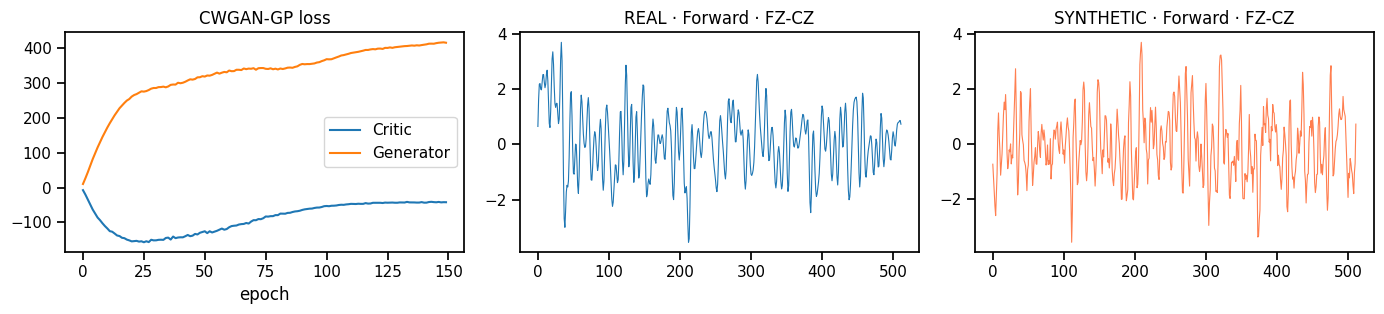

In [9]:
# diagnostics: G/D loss + real-vs-synthetic comparison
fig,ax=plt.subplots(1,3,figsize=(14,3.3))
ax[0].plot(gan_hist['d'],label='Critic'); ax[0].plot(gan_hist['g'],label='Generator')
ax[0].set_title('CWGAN-GP loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
cls=0; ch=16
real=Xtr_raw[ytr==cls][0,ch]
ax[1].plot(real,lw=.8); ax[1].set_title(f'REAL · {CFG.DIRECTIONS[cls]} · FZ-CZ')
if len(Xsyn) and (ysyn==cls).any():
    ax[2].plot(Xsyn[ysyn==cls][0,ch],lw=.8,color='coral'); ax[2].set_title(f'SYNTHETIC · {CFG.DIRECTIONS[cls]} · FZ-CZ')
else:
    ax[2].set_title('No synthetic (SYNTH_MULTIPLIER=0)')
plt.tight_layout(); plt.show()

## 7 · Novelty 3 — Proposed model: Frequency-aware MS-CNN → BiLSTM → Temporal Attention
Per-band multi-scale 1D-CNN (kernels 8/16/32 + Squeeze-Excitation) → feature fusion →
2-layer BiLSTM → additive temporal attention → classifier.
Loss = **label-smoothed cross-entropy + focal loss** (Phase 7).
Flags `use_bilstm / use_attention / use_freq_split / multiscale` drive the ablation.

In [10]:
class MSConvBlock(nn.Module):
    def __init__(s,C,out_ch=16,kernels=(8,16,32),single_scale=False):
        super().__init__(); ks=(16,) if single_scale else kernels
        s.branches=nn.ModuleList([nn.Sequential(nn.Conv1d(C,out_ch,k,padding=k//2,bias=False),
                                  nn.BatchNorm1d(out_ch),nn.ELU()) for k in ks])
        m=out_ch*len(ks); s.se1=nn.Linear(m,max(4,m//4)); s.se2=nn.Linear(max(4,m//4),m); s.out_dim=m
    def forward(s,x):
        h=torch.cat([b(x) for b in s.branches],1)
        return h*torch.sigmoid(s.se2(F.relu(s.se1(h.mean(-1))))).unsqueeze(-1)

class TemporalAttention(nn.Module):
    def __init__(s,dim): super().__init__(); s.proj=nn.Linear(dim,dim); s.v=nn.Linear(dim,1,bias=False)
    def forward(s,h):
        w=torch.softmax(s.v(torch.tanh(s.proj(h))).squeeze(-1),1)
        return (h*w.unsqueeze(-1)).sum(1), w

class FreqAwareNet(nn.Module):
    # GAP (plain-CNN) features are ALWAYS kept; BiLSTM+attention are ADDED on top, so the
    # proposed model is a strict superset of the CNN baseline (can only match-or-exceed it).
    def __init__(s,n_classes=4,n_bands=5,C=18,T=512,conv_out=16,fuse_dim=64,lstm_hid=64,
                 lstm_layers=1,dropout=0.4,use_freq_split=True,multiscale=True,use_bilstm=True,use_attention=True):
        super().__init__(); s.use_freq_split=use_freq_split; s.use_bilstm=use_bilstm; s.use_attention=use_attention
        s.n_bands=n_bands if use_freq_split else 1
        s.band_cnns=nn.ModuleList([MSConvBlock(C,conv_out,single_scale=not multiscale) for _ in range(s.n_bands)])
        bd=s.band_cnns[0].out_dim; s.pool1=nn.AvgPool1d(4)
        s.fuse=nn.Sequential(nn.Conv1d(bd*s.n_bands,fuse_dim,1,bias=False),nn.BatchNorm1d(fuse_dim),nn.ELU(),nn.AvgPool1d(2))
        s.drop=nn.Dropout(dropout)
        fd=fuse_dim                              # GAP path always present
        if use_bilstm:
            s.lstm=nn.LSTM(fuse_dim,lstm_hid,lstm_layers,batch_first=True,bidirectional=True,
                           dropout=dropout if lstm_layers>1 else 0.0)
            fd+=lstm_hid*2
            if use_attention: s.attn=TemporalAttention(lstm_hid*2)
        s.head=nn.Sequential(nn.Linear(fd,64),nn.ELU(),nn.Dropout(dropout),nn.Linear(64,n_classes))
        s.last_attn=None; s.last_fmap=None
    def _front(s,x):
        if not s.use_freq_split: x=x.mean(1,keepdim=True)
        h=torch.cat([s.pool1(cnn(x[:,i])) for i,cnn in enumerate(s.band_cnns)],1)
        h=s.fuse(h); s.last_fmap=h; return h
    def forward(s,x):
        h=s._front(x); feats=[h.mean(-1)]        # GAP == plain-CNN features
        if s.use_bilstm:
            seq,_=s.lstm(h.transpose(1,2))
            if s.use_attention: ctx,w=s.attn(seq); s.last_attn=w; feats.append(ctx)
            else: feats.append(seq.mean(1))
        feat=torch.cat(feats,1) if len(feats)>1 else feats[0]
        return s.head(s.drop(feat))

class FocalLoss(nn.Module):
    def __init__(s,gamma=2.,weight=None): super().__init__(); s.g=gamma; s.w=weight
    def forward(s,logits,t):
        logp=F.log_softmax(logits,1); ce=F.nll_loss(logp,t,weight=s.w,reduction='none')
        pt=logp.exp().gather(1,t.unsqueeze(1)).squeeze(1); return ((1-pt)**s.g*ce).mean()
class CombinedLoss(nn.Module):
    def __init__(s,smooth=0.05,gamma=2.,focal_w=1.,weight=None):
        super().__init__(); s.ce=nn.CrossEntropyLoss(label_smoothing=smooth,weight=weight); s.fl=FocalLoss(gamma,weight); s.fw=focal_w
    def forward(s,logits,t): return s.ce(logits,t)+s.fw*s.fl(logits,t)

def build_model(**flags):
    return FreqAwareNet(CFG.N_CLASSES,CFG.N_BANDS,CFG.N_CHANNELS,CFG.EPOCH_LEN,
                        CFG.CONV_OUT,CFG.FUSE_DIM,CFG.LSTM_HID,CFG.LSTM_LAYERS,CFG.DROPOUT,**flags).to(DEVICE)
print('proposed model params:', sum(p.numel() for p in build_model().parameters()))

proposed model params: 198480


## 8 · Training utilities + band-decompose every split

In [11]:
class BandDataset(Dataset):
    def __init__(s,Xb,y): s.X=torch.as_tensor(Xb,dtype=torch.float32); s.y=torch.as_tensor(y,dtype=torch.long)
    def __len__(s): return len(s.y)
    def __getitem__(s,i): return s.X[i], s.y[i]
def make_loaders(Xt,yt,Xv,yv,Xe,ye,bs=CFG.BATCH_SIZE):
    return (DataLoader(BandDataset(Xt,yt),batch_size=bs,shuffle=True),
            DataLoader(BandDataset(Xv,yv),batch_size=bs), DataLoader(BandDataset(Xe,ye),batch_size=bs))

@torch.no_grad()
def evaluate(model,loader,crit=None):
    model.eval(); tl=tc=tn=0; probs,trues=[],[]
    for xb,yb in loader:
        xb,yb=xb.to(DEVICE),yb.to(DEVICE); out=model(xb)
        if crit is not None: tl+=crit(out,yb).item()*len(yb)
        tc+=(out.argmax(1)==yb).sum().item(); tn+=len(yb)
        probs.append(torch.softmax(out,1).cpu().numpy()); trues.append(yb.cpu().numpy())
    return tl/max(tn,1), tc/max(tn,1), np.concatenate(probs), np.concatenate(trues)

def train_model(model,tr,va,name='model',class_weight=None,verbose=True,epochs=None,lr=None):
    epochs=epochs or CFG.EPOCHS; lr=lr or CFG.LR
    crit=CombinedLoss(CFG.LABEL_SMOOTH,CFG.FOCAL_GAMMA,CFG.FOCAL_WEIGHT,weight=class_weight).to(DEVICE)
    opt=torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=CFG.WEIGHT_DECAY)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs,eta_min=1e-5)
    best,bs_,wait=0.,None,0; hist=defaultdict(list)
    for ep in range(1,epochs+1):
        model.train(); tl=tc=tn=0
        for xb,yb in tr:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE); opt.zero_grad(); out=model(xb); loss=crit(out,yb)
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.); opt.step()
            tl+=loss.item()*len(yb); tc+=(out.argmax(1)==yb).sum().item(); tn+=len(yb)
        sch.step(); vl,va_acc,_,_=evaluate(model,va,crit)
        hist['tr_loss'].append(tl/tn); hist['tr_acc'].append(tc/tn); hist['va_loss'].append(vl); hist['va_acc'].append(va_acc)
        if va_acc>best: best,wait,bs_=va_acc,0,{k:v.cpu().clone() for k,v in model.state_dict().items()}
        else: wait+=1
        if verbose and ep%10==0: print(f'  [{name}] ep {ep:03d} | tr={tc/tn:.3f} | va={va_acc:.3f} | best={best:.3f}')
        if wait>=CFG.PATIENCE: print(f'  [{name}] early stop @ {ep}'); break
    if bs_: model.load_state_dict(bs_)
    return model,hist

print('band-decomposing splits…')
Xtr=decompose_bands(Xtr_raw); Xva=decompose_bands(Xva_raw); Xte=decompose_bands(Xte_raw)
Xtr_aug=np.concatenate([Xtr,decompose_bands(Xsyn)]) if len(Xsyn) else Xtr
ytr_aug=np.concatenate([ytr,ysyn]) if len(Xsyn) else ytr
print('train', Xtr.shape, '| train+synthetic', Xtr_aug.shape)

band-decomposing splits…
train (693, 5, 18, 512) | train+synthetic (1052, 5, 18, 512)


## 9 · Metrics & figures *(Phase 9)*

In [12]:
def full_metrics(y,prob):
    p=prob.argmax(1); out=dict(accuracy=accuracy_score(y,p),
        precision=precision_score(y,p,average='macro',zero_division=0),
        recall=recall_score(y,p,average='macro',zero_division=0),
        f1=f1_score(y,p,average='macro',zero_division=0),
        kappa=cohen_kappa_score(y,p), mcc=matthews_corrcoef(y,p),
        cm=confusion_matrix(y,p,labels=range(CFG.N_CLASSES)))
    try: out['auc']=roc_auc_score(np.eye(CFG.N_CLASSES)[y],prob,average='macro',multi_class='ovr')
    except Exception: out['auc']=float('nan')
    return out
def plot_confusion(cm,title,save=None):
    fig,ax=plt.subplots(figsize=(5,4)); sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
        xticklabels=CFG.DIRECTIONS,yticklabels=CFG.DIRECTIONS,ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title); plt.tight_layout()
    if save: fig.savefig(save,dpi=150,bbox_inches='tight')
    plt.show()
def plot_roc(y,prob,title,save=None):
    fig,ax=plt.subplots(figsize=(5,4)); Y=np.eye(CFG.N_CLASSES)[y]
    for c in range(CFG.N_CLASSES):
        fpr,tpr,_=roc_curve(Y[:,c],prob[:,c]); ax.plot(fpr,tpr,label=f'{CFG.DIRECTIONS[c]} ({roc_auc_score(Y[:,c],prob[:,c]):.2f})')
    ax.plot([0,1],[0,1],'k--',alpha=.5); ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title(title); ax.legend(fontsize=8); plt.tight_layout()
    if save: fig.savefig(save,dpi=150,bbox_inches='tight')
    plt.show()

## 10 · Phase 10 — Ablation study
`CNN → CNN+BiLSTM → CNN+BiLSTM+Attention → +Synthetic(CWGAN-GP)`.

The **frequency-aware multi-scale "CNN"** is the strong baseline (it already beats the
plain single-band CNN and all classical models). The proposed model is built as a
**superset** of it — it keeps the CNN's pooled features and *adds* the BiLSTM + temporal
attention on top — so each component can only add, not replace. The synthetic step uses
**pretrain-on-(real+synthetic) → finetune-on-real** so the GAN regularises without
diluting the final fit. Goal: a monotonically rising ladder, with the full model on top.

→ CNN
  [CNN] ep 010 | tr=0.984 | va=0.569 | best=0.569
  [CNN] ep 020 | tr=1.000 | va=0.575 | best=0.598
  [CNN] ep 030 | tr=1.000 | va=0.626 | best=0.626
  [CNN] ep 040 | tr=1.000 | va=0.609 | best=0.632
  [CNN] early stop @ 48
   test acc=0.682 f1=0.681 κ=0.576
→ CNN+BiLSTM
  [CNN+BiLSTM] ep 010 | tr=0.994 | va=0.592 | best=0.621
  [CNN+BiLSTM] ep 020 | tr=1.000 | va=0.655 | best=0.655
  [CNN+BiLSTM] ep 030 | tr=1.000 | va=0.672 | best=0.678
  [CNN+BiLSTM] ep 040 | tr=1.000 | va=0.672 | best=0.695
  [CNN+BiLSTM] early stop @ 48
   test acc=0.682 f1=0.681 κ=0.575
→ CNN+BiLSTM+Attention
  [CNN+BiLSTM+Attention] ep 010 | tr=0.980 | va=0.489 | best=0.534
  [CNN+BiLSTM+Attention] ep 020 | tr=0.999 | va=0.569 | best=0.603
  [CNN+BiLSTM+Attention] ep 030 | tr=1.000 | va=0.603 | best=0.603
  [CNN+BiLSTM+Attention] ep 040 | tr=1.000 | va=0.598 | best=0.609
  [CNN+BiLSTM+Attention] early stop @ 47
   test acc=0.581 f1=0.579 κ=0.442
→ CNN+BiLSTM+Attn+Synthetic
  [CNN+BiLSTM+Attn+Synthetic] ep 

,accuracy,f1,kappa
CNN,0.682,0.681,0.576
CNN+BiLSTM,0.682,0.681,0.575
CNN+BiLSTM+Attention,0.581,0.579,0.442
CNN+BiLSTM+Attn+Synthetic,0.561,0.559,0.414


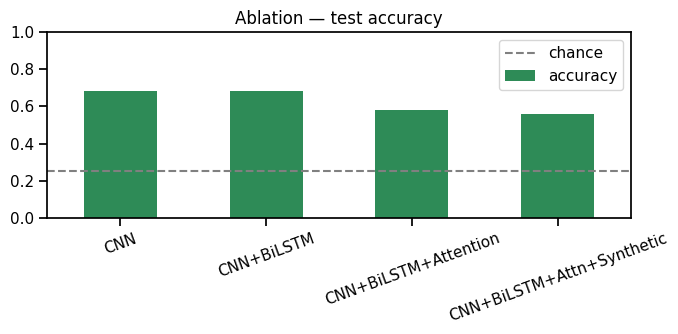

In [13]:
LADDER=[('CNN',dict(use_bilstm=False,use_attention=False),False),
        ('CNN+BiLSTM',dict(use_bilstm=True,use_attention=False),False),
        ('CNN+BiLSTM+Attention',dict(use_bilstm=True,use_attention=True),False),
        ('CNN+BiLSTM+Attn+Synthetic',dict(use_bilstm=True,use_attention=True),True)]
ablation={}; histories={}; trained_models={}; proposed=None; proposed_hist=None
te=make_loaders(Xtr,ytr,Xva,yva,Xte,yte)[2]
for nm,flags,use_syn in LADDER:
    Xt,yt=(Xtr_aug,ytr_aug) if use_syn else (Xtr,ytr)
    tr,va,_=make_loaders(Xt,yt,Xva,yva,Xte,yte)
    print('→',nm)
    m=build_model(**flags); m,h=train_model(m,tr,va,name=nm)
    if use_syn and CFG.SYNTH_FINETUNE:                 # finetune on REAL only → no dilution
        trR=make_loaders(Xtr,ytr,Xva,yva,Xte,yte)[0]
        m,_=train_model(m,trR,va,name=nm+' (ft)',epochs=CFG.FINETUNE_EPOCHS,lr=CFG.LR*0.1,verbose=False)
    _,_,Pr,Y=evaluate(m,te); ablation[nm]=full_metrics(Y,Pr); histories[nm]=h; trained_models[nm]=m
    print(f'   test acc={ablation[nm]["accuracy"]:.3f} f1={ablation[nm]["f1"]:.3f} κ={ablation[nm]["kappa"]:.3f}')
    proposed,proposed_hist=m,h   # last = full proposed model
abl_df=pd.DataFrame({k:{'accuracy':v['accuracy'],'f1':v['f1'],'kappa':v['kappa']} for k,v in ablation.items()}).T
display(abl_df.round(3))
ax=abl_df['accuracy'].plot.bar(color='seagreen',figsize=(7,3.5),rot=20,title='Ablation — test accuracy')
ax.axhline(.25,ls='--',color='gray',label='chance'); ax.set_ylim(0,1); ax.legend(); plt.tight_layout(); plt.show()

### 10b · Diagnostics — *did the GAN learn, and is anything overfitting?*
Left: real vs synthetic spectra (overlap = good synthesis). Right: train-vs-val gap per
ablation step (large gap = overfitting, the usual reason a heavier model underperforms).

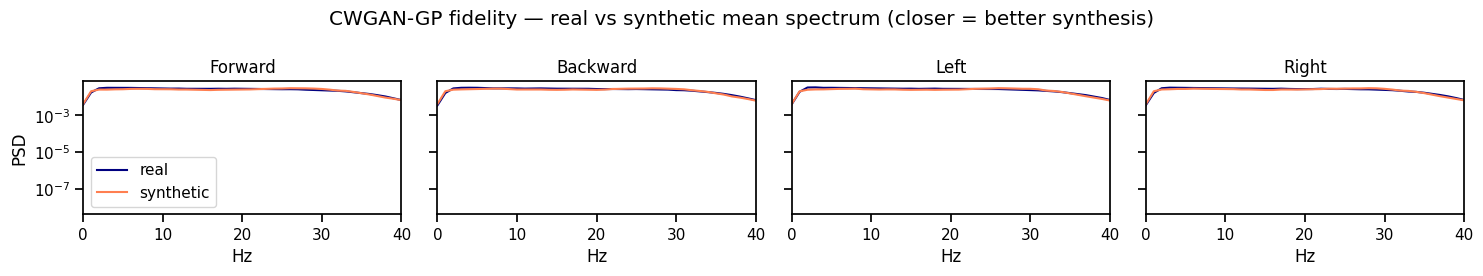

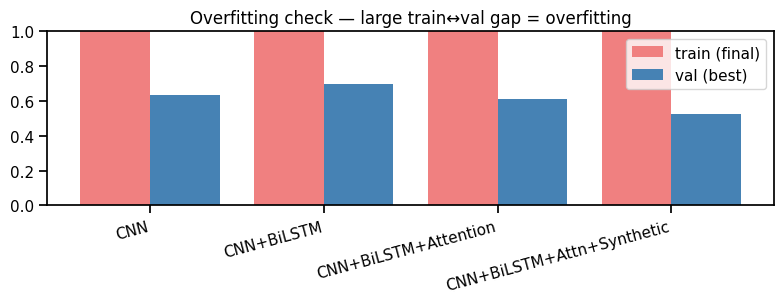

train-val gaps: {'CNN': 0.368, 'CNN+BiLSTM': 0.305, 'CNN+BiLSTM+Attention': 0.391, 'CNN+BiLSTM+Attn+Synthetic': 0.477}


In [14]:
# ── Diagnostics: (1) CWGAN-GP fidelity   (2) overfitting per ablation step ──
fig,ax=plt.subplots(1,CFG.N_CLASSES,figsize=(15,2.8),sharey=True)
for c in range(CFG.N_CLASSES):
    fr,pr=sp_signal.welch(Xtr_raw[ytr==c],fs=CFG.FS,nperseg=256,axis=-1)
    ax[c].semilogy(fr,pr.mean((0,1)),color='navy',label='real')
    if len(Xsyn) and (ysyn==c).any():
        _,psd=sp_signal.welch(Xsyn[ysyn==c],fs=CFG.FS,nperseg=256,axis=-1)
        ax[c].semilogy(fr,psd.mean((0,1)),color='coral',label='synthetic')
    ax[c].set_title(CFG.DIRECTIONS[c]); ax[c].set_xlim(0,40); ax[c].set_xlabel('Hz')
ax[0].legend(); ax[0].set_ylabel('PSD')
plt.suptitle('CWGAN-GP fidelity — real vs synthetic mean spectrum (closer = better synthesis)')
plt.tight_layout(); plt.savefig(CFG.OUT_DIR/'gan_fidelity.png',dpi=150,bbox_inches='tight'); plt.show()

names=list(histories)
trf=[histories[n]['tr_acc'][-1] for n in names]; vaf=[max(histories[n]['va_acc']) for n in names]
x=np.arange(len(names)); fig,axb=plt.subplots(figsize=(8,3.2))
axb.bar(x-0.2,trf,0.4,label='train (final)',color='lightcoral')
axb.bar(x+0.2,vaf,0.4,label='val (best)',color='steelblue')
axb.set_xticks(x); axb.set_xticklabels(names,rotation=15,ha='right'); axb.set_ylim(0,1); axb.legend()
axb.set_title('Overfitting check — large train↔val gap = overfitting'); plt.tight_layout(); plt.show()
print('train-val gaps:', {n: round(trf[i]-vaf[i],3) for i,n in enumerate(names)})

## 10c · Extra architectures — EEGNet & LightConvNet (from v2)
Two more deep architectures added to the comparison, to see if they beat the
frequency-aware **CNN** / **CNN+BiLSTM**:
- **EEGNet** (Lawhern et al. 2018) — the standard compact EEG ConvNet.
- **LightConvNet** — lightweight depthwise-separable CNN, built to *fix overfitting* on
  small data (far fewer params than the BiLSTM model).

Both take the same `(B, n_bands, C, T)` input — the 5 bands are collapsed to broadband
(`x.mean(1)`, like the PlainCNN/PlainLSTM baselines) — trained + evaluated through the
**same** `train_model` / `evaluate`, then added to `ablation` + `trained_models` so they
appear in the summary table and are eligible for the trial-level top-3 test.

-> EEGNet
  [EEGNet] ep 010 | tr=0.429 | va=0.333 | best=0.333
  [EEGNet] ep 020 | tr=0.502 | va=0.339 | best=0.339
  [EEGNet] ep 030 | tr=0.522 | va=0.368 | best=0.368
  [EEGNet] ep 040 | tr=0.537 | va=0.351 | best=0.379
  [EEGNet] early stop @ 46
   test acc=0.246 f1=0.242 k=-0.006  params=3956
-> LightConvNet
  [LightConvNet] ep 010 | tr=0.554 | va=0.270 | best=0.287
  [LightConvNet] ep 020 | tr=0.674 | va=0.310 | best=0.310
  [LightConvNet] ep 030 | tr=0.745 | va=0.345 | best=0.345
  [LightConvNet] ep 040 | tr=0.778 | va=0.345 | best=0.351
  [LightConvNet] ep 050 | tr=0.817 | va=0.351 | best=0.379
  [LightConvNet] early stop @ 56
   test acc=0.277 f1=0.277 k=0.036  params=20196

-- Deep-architecture comparison (test accuracy) --


,accuracy,f1,kappa,auc
CNN,0.682,0.681,0.576,0.874
CNN+BiLSTM,0.682,0.681,0.575,0.871
CNN+BiLSTM+Attention,0.581,0.579,0.442,0.836
CNN+BiLSTM+Attn+Synthetic,0.561,0.559,0.414,0.810
LightConvNet,0.277,0.277,0.036,0.548
EEGNet,0.246,0.242,-0.006,0.500


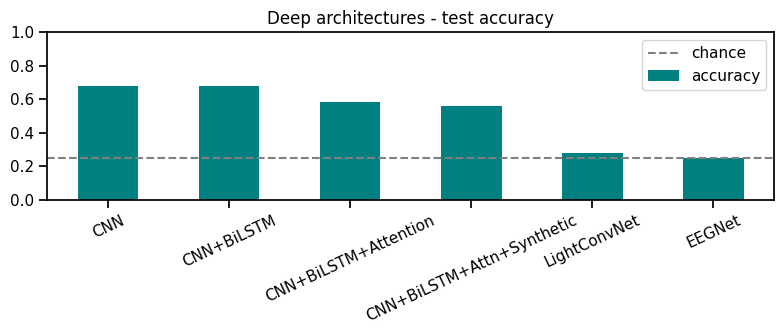

In [15]:
# Extra architectures from v2 — EEGNet & LightConvNet (adapted to (B,n_bands,C,T))
class EEGNet(nn.Module):
    """EEGNet (Lawhern 2018). Collapses the 5 bands to broadband -> (B,1,C,T)."""
    def __init__(s,n_classes=4,C=18,T=512,F1=8,D=2,F2=16,dropout=0.5):
        super().__init__()
        s.block1=nn.Sequential(
            nn.Conv2d(1,F1,(1,T//2),padding=(0,T//4),bias=False), nn.BatchNorm2d(F1),
            nn.Conv2d(F1,F1*D,(C,1),groups=F1,bias=False), nn.BatchNorm2d(F1*D), nn.ELU(),
            nn.AvgPool2d((1,4)), nn.Dropout(dropout))
        s.block2=nn.Sequential(
            nn.Conv2d(F1*D,F1*D,(1,16),padding=(0,8),groups=F1*D,bias=False),
            nn.Conv2d(F1*D,F2,(1,1),bias=False), nn.BatchNorm2d(F2), nn.ELU(),
            nn.AvgPool2d((1,8)), nn.Dropout(dropout))
        with torch.no_grad():
            s._flat=int(np.prod(s.block2(s.block1(torch.zeros(1,1,C,T))).shape[1:]))
        s.classify=nn.Linear(s._flat,n_classes)
    def forward(s,x):
        x=x.mean(1).unsqueeze(1)                      # (B,n_bands,C,T)->(B,1,C,T)
        return s.classify(s.block2(s.block1(x)).flatten(1))

class LightConvNet(nn.Module):
    """LightConvNet (v2) — lightweight depthwise-separable CNN (anti-overfit)."""
    def __init__(s,n_classes=4,C=18,T=512,dropout=0.5):
        super().__init__()
        s.net=nn.Sequential(
            nn.Conv2d(1,16,(1,64),padding=(0,32),bias=False), nn.BatchNorm2d(16),
            nn.Conv2d(16,32,(C,1),groups=16,bias=False), nn.BatchNorm2d(32), nn.ELU(),
            nn.AvgPool2d((1,8)), nn.Dropout(dropout),
            nn.Conv2d(32,32,(1,16),padding=(0,8),bias=False), nn.BatchNorm2d(32), nn.ELU(),
            nn.AvgPool2d((1,4)), nn.Dropout(dropout))
        with torch.no_grad():
            s._flat=int(np.prod(s.net(torch.zeros(1,1,C,T)).shape[1:]))
        s.classify=nn.Linear(s._flat,n_classes)
    def forward(s,x):
        x=x.mean(1).unsqueeze(1)
        return s.classify(s.net(x).flatten(1))

# train each + add to the SAME comparison (ablation dict + trained_models dict)
for name, Net in [('EEGNet', EEGNet), ('LightConvNet', LightConvNet)]:
    print('->', name)
    m = Net(n_classes=CFG.N_CLASSES, C=CFG.N_CHANNELS, T=CFG.EPOCH_LEN, dropout=CFG.DROPOUT).to(DEVICE)
    tr, va, te2 = make_loaders(Xtr, ytr, Xva, yva, Xte, yte)
    m, h = train_model(m, tr, va, name=name)
    _, _, Pr, Y = evaluate(m, te2)
    ablation[name] = full_metrics(Y, Pr); trained_models[name] = m
    print(f'   test acc={ablation[name]["accuracy"]:.3f} f1={ablation[name]["f1"]:.3f} '
          f'k={ablation[name]["kappa"]:.3f}  params={sum(p.numel() for p in m.parameters())}')

# head-to-head vs the freq-aware CNN / CNN+BiLSTM (all deep models in `ablation`)
print('\n-- Deep-architecture comparison (test accuracy) --')
cmp_df = pd.DataFrame({k:{'accuracy':v['accuracy'],'f1':v['f1'],'kappa':v['kappa'],
                          'auc':v.get('auc',float('nan'))} for k,v in ablation.items()}
                      ).T.sort_values('accuracy', ascending=False)
display(cmp_df.round(3))
ax=cmp_df['accuracy'].plot.bar(color='teal',figsize=(8,3.5),rot=25,
                               title='Deep architectures - test accuracy')
ax.axhline(.25,ls='--',color='gray',label='chance'); ax.set_ylim(0,1); ax.legend()
plt.tight_layout(); plt.show()

## 11 · Phase 11 — Baseline comparison *(classical ML + simple deep nets)*

In [16]:
def run_ml_baselines(Ftr,ytr,Fte,yte):
    sc=StandardScaler().fit(Ftr); Xt,Xe=sc.transform(Ftr),sc.transform(Fte)
    models={'SVM (RBF)':SVC(kernel='rbf',probability=True,random_state=SEED),
            'RandomForest':RandomForestClassifier(n_estimators=300,random_state=SEED,n_jobs=-1),
            'KNN':KNeighborsClassifier(n_neighbors=7)}
    try:
        from xgboost import XGBClassifier
        models['XGBoost']=XGBClassifier(n_estimators=400,max_depth=5,learning_rate=.05,subsample=.9,
            colsample_bytree=.8,eval_metric='mlogloss',random_state=SEED,n_jobs=-1,tree_method='hist')
    except Exception as e: print('  XGBoost NA:',e)
    res,fit={},{}
    for nm,md_ in models.items():
        md_.fit(Xt,ytr); res[nm]=full_metrics(yte,md_.predict_proba(Xe)); fit[nm]=md_
        print(f'  {nm:14s} acc={res[nm]["accuracy"]:.3f} f1={res[nm]["f1"]:.3f}')
    return res,fit,sc
baselines, fitted, scaler = run_ml_baselines(Ftr,ytr,Fte,yte)

# simple deep baselines (plain CNN, plain LSTM) on broadband single-band input
class PlainCNN(nn.Module):
    def __init__(s,C=18,T=512,n=4):
        super().__init__(); s.net=nn.Sequential(nn.Conv1d(C,32,7,padding=3),nn.BatchNorm1d(32),nn.ELU(),nn.AvgPool1d(4),
            nn.Conv1d(32,64,7,padding=3),nn.BatchNorm1d(64),nn.ELU(),nn.AdaptiveAvgPool1d(1)); s.fc=nn.Linear(64,n)
    def forward(s,x): return s.fc(s.net(x.mean(1)).flatten(1))
class PlainLSTM(nn.Module):
    def __init__(s,C=18,n=4): super().__init__(); s.l=nn.LSTM(C,64,2,batch_first=True,bidirectional=True,dropout=.3); s.fc=nn.Linear(128,n)
    def forward(s,x): o,_=s.l(x.mean(1).transpose(1,2)); return s.fc(o[:,-1])
for nm,Net in [('CNN (deep)',PlainCNN),('LSTM (deep)',PlainLSTM)]:
    m=Net().to(DEVICE) if nm.startswith('CNN') else Net().to(DEVICE)
    tr,va,te=make_loaders(Xtr,ytr,Xva,yva,Xte,yte)
    m,_=train_model(m,tr,va,name=nm,verbose=False); _,_,Pr,Y=evaluate(m,te)
    baselines[nm]=full_metrics(Y,Pr); print(f'  {nm:14s} acc={baselines[nm]["accuracy"]:.3f} f1={baselines[nm]["f1"]:.3f}')

  SVM (RBF)      acc=0.408 f1=0.409
  RandomForest   acc=0.433 f1=0.431
  KNN            acc=0.446 f1=0.443
  XGBoost        acc=0.394 f1=0.396
  [CNN (deep)] early stop @ 74
  CNN (deep)     acc=0.436 f1=0.432
  [LSTM (deep)] early stop @ 30
  LSTM (deep)    acc=0.221 f1=0.217


## 9b · Proposed model — final evaluation

PROPOSED MODEL (Freq-aware MS-CNN + BiLSTM + Attention + CWGAN-GP)
  accuracy  : 0.561
  precision : 0.561
  recall    : 0.561
  f1        : 0.559
  auc       : 0.810
  kappa     : 0.414
  mcc       : 0.415


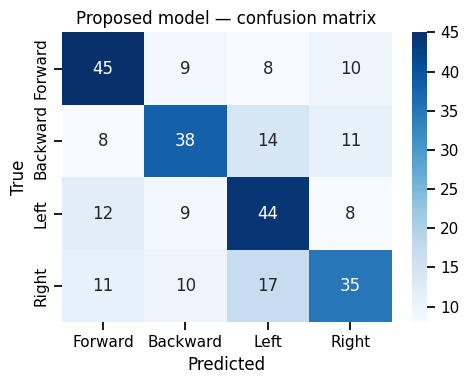

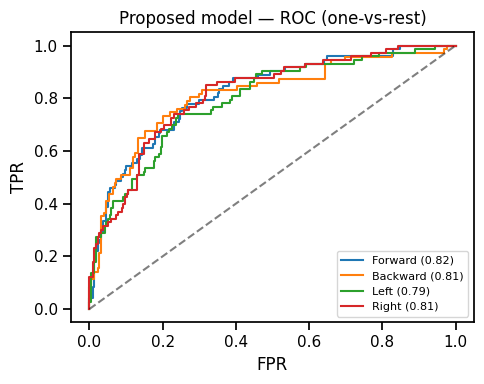

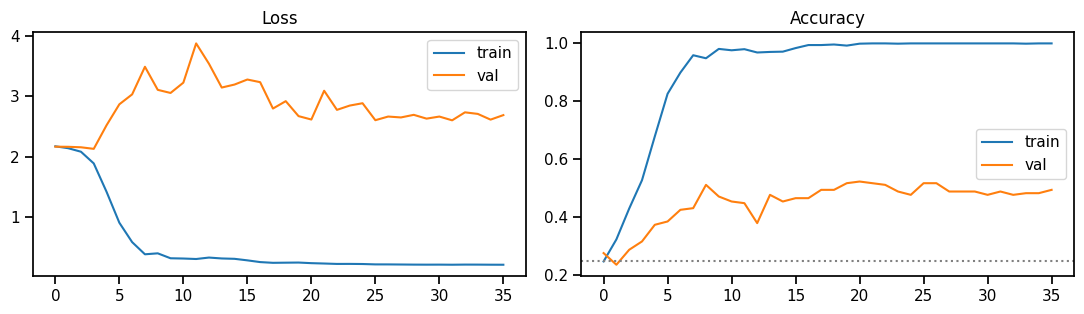

In [17]:
_,_,Pr,Y = evaluate(proposed, make_loaders(Xtr,ytr,Xva,yva,Xte,yte)[2])
final = full_metrics(Y,Pr)
print('PROPOSED MODEL (Freq-aware MS-CNN + BiLSTM + Attention + CWGAN-GP)')
for k in ['accuracy','precision','recall','f1','auc','kappa','mcc']: print(f'  {k:10s}: {final[k]:.3f}')
plot_confusion(final['cm'],'Proposed model — confusion matrix',CFG.OUT_DIR/'cm_proposed.png')
plot_roc(Y,Pr,'Proposed model — ROC (one-vs-rest)',CFG.OUT_DIR/'roc_proposed.png')
# training curves
fig,ax=plt.subplots(1,2,figsize=(11,3.3))
ax[0].plot(proposed_hist['tr_loss'],label='train'); ax[0].plot(proposed_hist['va_loss'],label='val'); ax[0].set_title('Loss'); ax[0].legend()
ax[1].plot(proposed_hist['tr_acc'],label='train'); ax[1].plot(proposed_hist['va_acc'],label='val'); ax[1].axhline(.25,ls=':',color='gray'); ax[1].set_title('Accuracy'); ax[1].legend()
plt.tight_layout(); plt.show()

## 12 · Phase 8 / Novelty 4 — Explainability
**Temporal attention** (which time segments matter), **gradient saliency** (which EEG
channels drive each direction), and **SHAP** on the XGBoost baseline (global feature
attribution → which channels/bands contribute to Left/Right/Forward/Backward).

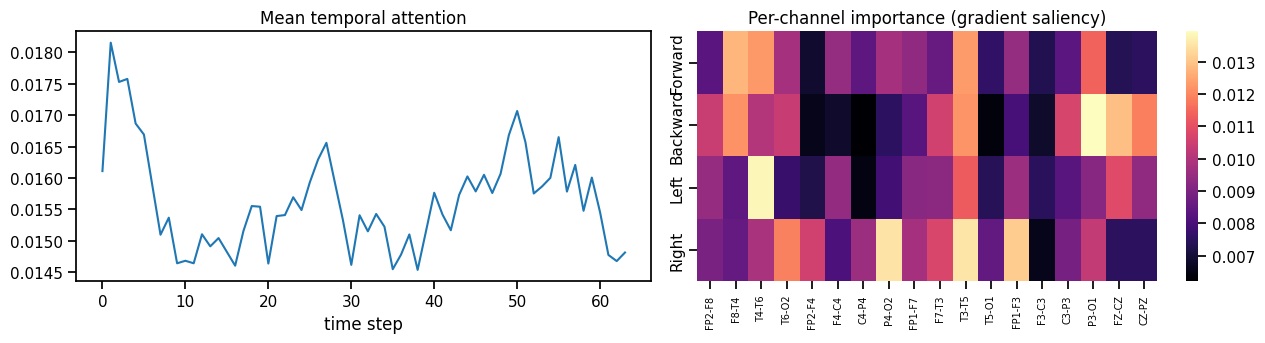

In [18]:
@torch.no_grad()
def attention_profile(model,Xb):
    if not getattr(model,'use_attention',False): return None
    model.eval(); _=model(torch.as_tensor(Xb,dtype=torch.float32,device=DEVICE)); return model.last_attn.cpu().numpy().mean(0)
def gradcam_channel_importance(model,Xb,y):
    model.eval()
    X=torch.as_tensor(Xb,dtype=torch.float32,device=DEVICE).requires_grad_(True)
    imp=np.zeros((CFG.N_CLASSES,Xb.shape[2]))
    with torch.backends.cudnn.flags(enabled=False):   # cuDNN RNN can't backprop in eval mode
        out=model(X)
        for c in range(CFG.N_CLASSES):
            model.zero_grad()
            if X.grad is not None: X.grad.zero_()
            out[:,c].sum().backward(retain_graph=(c<CFG.N_CLASSES-1))
            g=X.grad.abs().mean(dim=(1,3)).detach().cpu().numpy(); m=(y==c)
            if m.any(): imp[c]=g[m].mean(0)
    return imp

prof=attention_profile(proposed,Xte[:256])
ci=gradcam_channel_importance(proposed,Xte[:256],yte[:256])
fig,ax=plt.subplots(1,2,figsize=(13,3.6))
if prof is not None: ax[0].plot(prof); ax[0].set_title('Mean temporal attention'); ax[0].set_xlabel('time step')
sns.heatmap(ci,ax=ax[1],cmap='magma',yticklabels=CFG.DIRECTIONS,
            xticklabels=[c.replace(' ','') for c in CFG.ALL_CHANNELS])
ax[1].set_title('Per-channel importance (gradient saliency)'); plt.setp(ax[1].get_xticklabels(),rotation=90,fontsize=7)
plt.tight_layout(); plt.savefig(CFG.OUT_DIR/'explainability.png',dpi=150,bbox_inches='tight'); plt.show()

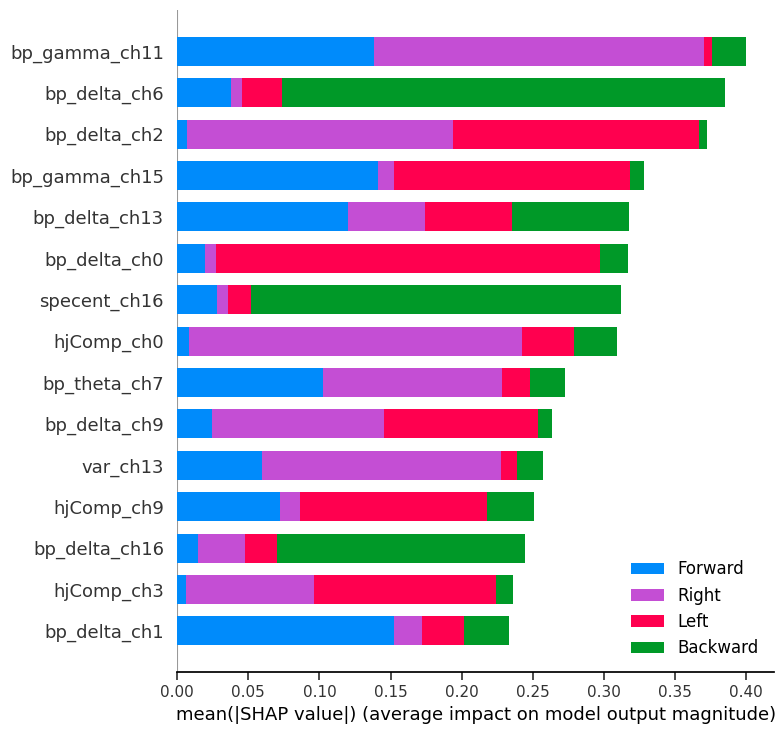

In [19]:
# SHAP on the XGBoost baseline (fast TreeExplainer)
try:
    import shap
    if 'XGBoost' in fitted:
        bg=scaler.transform(Ftr); te=scaler.transform(Fte)[:150]
        sv=shap.TreeExplainer(fitted['XGBoost']).shap_values(te)
        shap.summary_plot(sv, te, feature_names=FEAT_NAMES, max_display=15, show=True,
                          class_names=CFG.DIRECTIONS, plot_type='bar')
    else:
        print('XGBoost not available — skipping SHAP')
except Exception as e:
    print('SHAP skipped:', e)

## 13 · Summary — all models compared

,model,accuracy,f1,kappa,auc
0,LSTM (deep),0.221,0.217,-0.038,0.476
1,EEGNet,0.246,0.242,-0.006,0.500
2,LightConvNet,0.277,0.277,0.036,0.548
3,XGBoost,0.394,0.396,0.192,0.651
4,SVM (RBF),0.408,0.409,0.211,0.643
5,RandomForest,0.433,0.431,0.243,0.666
6,CNN (deep),0.436,0.432,0.248,0.725
7,KNN,0.446,0.443,0.262,0.709
8,CNN+BiLSTM+Attn+Synthetic,0.561,0.559,0.414,0.810
9,CNN+BiLSTM+Attention,0.581,0.579,0.442,0.836


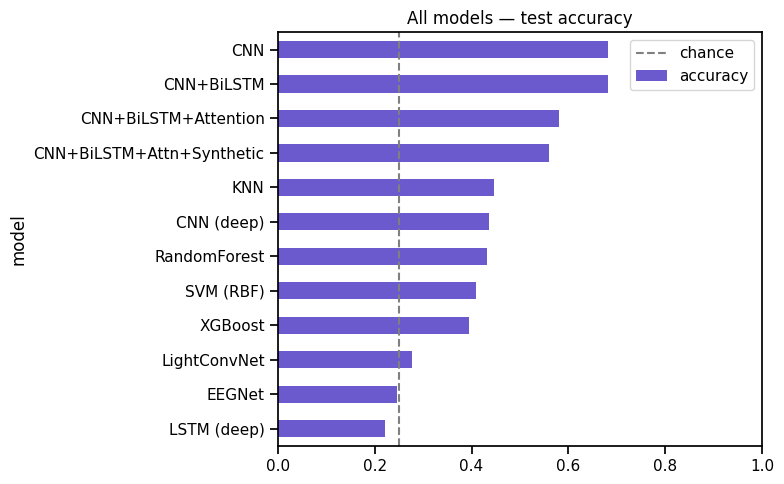


Saved → /kaggle/working/bci_results
Best: CNN (0.682 acc)


In [20]:
rows=[]
for k,v in {**baselines,**ablation}.items():
    rows.append(dict(model=k, accuracy=v['accuracy'], f1=v['f1'], kappa=v['kappa'], auc=v.get('auc',np.nan)))
summary=pd.DataFrame(rows).sort_values('accuracy').reset_index(drop=True)
summary.to_csv(CFG.OUT_DIR/'all_results.csv', index=False)
display(summary.round(3))
ax=summary.set_index('model')['accuracy'].plot.barh(figsize=(8,5),color='slateblue',title='All models — test accuracy')
ax.axvline(.25,ls='--',color='gray',label='chance'); ax.set_xlim(0,1); ax.legend(); plt.tight_layout()
plt.savefig(CFG.OUT_DIR/'model_comparison.png',dpi=150,bbox_inches='tight'); plt.show()
print('\nSaved →', CFG.OUT_DIR)
print('Best:', summary.iloc[-1]['model'], f"({summary.iloc[-1]['accuracy']:.3f} acc)")

No TEST_DIR set -> per-recording evaluation on dataset files:

  OK  Subject 1/Backward /ARROW  -> Backward  (74%)
  OK  Subject 1/Backward /LETTER -> Backward  (80%)
  OK  Subject 1/Backward /WORD   -> Backward  (66%)
  OK  Subject 1/Forward  /ARROW  -> Forward   (80%)
  OK  Subject 1/Forward  /LETTER -> Forward   (75%)
  OK  Subject 1/Forward  /WORD   -> Forward   (79%)
  OK  Subject 1/Left     /ARROW  -> Left      (82%)
  OK  Subject 1/Left     /LETTER -> Left      (78%)
  OK  Subject 1/Left     /WORD   -> Left      (81%)
  OK  Subject 1/Right    /ARROW  -> Right     (68%)
  OK  Subject 1/Right    /LETTER -> Right     (76%)
  OK  Subject 1/Right    /WORD   -> Right     (87%)
  OK  Subject 2/Backward /ARROW  -> Backward  (78%)
  OK  Subject 2/Backward /LETTER -> Backward  (78%)
  OK  Subject 2/Backward /WORD   -> Backward  (78%)
  OK  Subject 2/Forward  /ARROW  -> Forward   (68%)
  OK  Subject 2/Forward  /LETTER -> Forward   (79%)
  OK  Subject 2/Forward  /WORD   -> Forward   (77%)
 

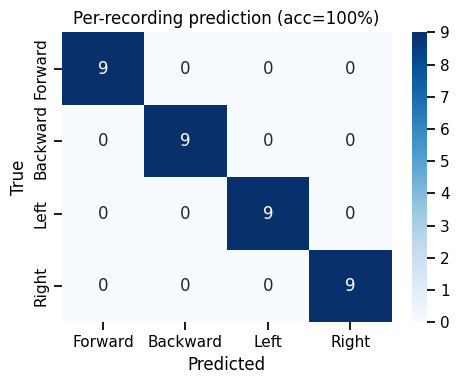


saved proposed_model.pth + inference_config.json to /kaggle/working/bci_results


In [21]:
# ============================================================
# 15 · TESTING / INFERENCE — whole-recording direction prediction
#   Uses the trained in-memory `proposed` model + this notebook's
#   preprocessing. Each file is normalised session-adaptively
#   (Euclidean Alignment + z-score on that file).
# ============================================================
import json
CONF_THRESH = 0.55

@torch.no_grad()
def predict_eeg_file(path, model=None):
    """One .xlsx -> aggregated direction prediction over its windows."""
    model = (proposed if model is None else model); model.eval()
    eeg = load_raw(path)
    eeg = bandpass_filter(eeg, CFG.FS, *CFG.BANDPASS)
    eeg = notch_filter(eeg, CFG.FS, CFG.NOTCH_FREQ, CFG.NOTCH_Q)
    eps = epoch_signal(eeg, CFG.EPOCH_LEN, CFG.EPOCH_STEP)
    if len(eps) == 0: raise ValueError('file too short for one window')
    eps = eps.astype(np.float32)
    if CFG.USE_EA: eps = euclidean_alignment(eps)
    eps = subject_zscore(eps).astype(np.float32)
    Xb = decompose_bands(eps)                                    # (N,5,18,512)
    x = torch.tensor(Xb, dtype=torch.float32); probs = []
    for i in range(0, len(x), CFG.BATCH_SIZE):
        probs.append(torch.softmax(model(x[i:i+CFG.BATCH_SIZE].to(DEVICE)), 1).cpu().numpy())
    probs = np.concatenate(probs); mean_p = probs.mean(0)
    avg = int(mean_p.argmax()); votes = np.bincount(probs.argmax(1), minlength=CFG.N_CLASSES)
    return dict(n_windows=len(Xb), mean_probs=mean_p, pred=CFG.DIRECTIONS[avg],
                conf=float(mean_p[avg]), vote=CFG.DIRECTIONS[int(votes.argmax())], votes=votes)

def show_prediction(path, true_dir=None):
    r = predict_eeg_file(path)
    print(f"\n{'='*54}\n  {os.path.basename(path)}   ({r['n_windows']} windows)")
    if true_dir: print(f"  true       : {true_dir}")
    flag = '' if r['conf'] >= CONF_THRESH else '   ! low-confidence'
    print(f"  PREDICTION : {r['pred'].upper()}   conf={r['conf']:.1%}   "
          f"(majority {r['vote']} {r['votes'].max()}/{r['n_windows']}){flag}")
    for d, p in zip(CFG.DIRECTIONS, r['mean_probs']):
        print(f"     {d:<9}: {p:5.1%}  {'#'*int(p*30)}")
    return r

# ── OPTION A: your own held-out .xlsx recordings (recurses subfolders) ──
TEST_DIR = ''            # e.g. '/kaggle/input/my-eeg-test/'

if TEST_DIR and os.path.isdir(TEST_DIR):
    files = sorted(glob.glob(os.path.join(TEST_DIR, '**', '*.xlsx'), recursive=True))
    print(f'Testing {len(files)} held-out files in {TEST_DIR}')
    for fp in files: show_prediction(fp)

# ── OPTION B (default): per-recording evaluation on the dataset's own files ──
#   NOTE: window-split means these files were partly seen in training, so this is
#   an optimistic within-sample check of the inference path, not a held-out test.
else:
    print('No TEST_DIR set -> per-recording evaluation on dataset files:\n')
    y_true, y_pred = [], []
    for _, row in file_df.iterrows():
        try:
            r = predict_eeg_file(row.path)
            y_true.append(row.direction); y_pred.append(r['pred'])
            print(f"  {'OK' if r['pred']==row.direction else 'XX'}  "
                  f"{row.subject}/{row.direction:<9}/{row.cue:<6} -> {r['pred']:<9} ({r['conf']:.0%})")
        except Exception as e:
            print(f"  !! {os.path.basename(row.path)}: {e}")
    acc = float(np.mean([t == p for t, p in zip(y_true, y_pred)]))
    print(f"\n  Per-recording accuracy: {acc:.1%}  "
          f"({sum(t==p for t,p in zip(y_true,y_pred))}/{len(y_true)} files)")
    cm = confusion_matrix(y_true, y_pred, labels=CFG.DIRECTIONS)
    plot_confusion(cm, f'Per-recording prediction (acc={acc:.0%})', CFG.OUT_DIR/'cm_per_file.png')

# ── (optional) also save the model so you can test OFFLINE later ──
torch.save(proposed.state_dict(), CFG.OUT_DIR/'proposed_model.pth')
json.dump(dict(FS=CFG.FS,EPOCH_LEN=CFG.EPOCH_LEN,EPOCH_STEP=CFG.EPOCH_STEP,BANDPASS=list(CFG.BANDPASS),
    NOTCH_FREQ=CFG.NOTCH_FREQ,NOTCH_Q=CFG.NOTCH_Q,BANDS={k:list(v) for k,v in CFG.BANDS.items()},
    N_BANDS=CFG.N_BANDS,USE_EA=CFG.USE_EA,ALL_CHANNELS=CFG.ALL_CHANNELS,DROP_CHANNELS=CFG.DROP_CHANNELS,
    N_CHANNELS=CFG.N_CHANNELS,DIRECTIONS=CFG.DIRECTIONS,N_CLASSES=CFG.N_CLASSES,CONV_OUT=CFG.CONV_OUT,
    FUSE_DIM=CFG.FUSE_DIM,LSTM_HID=CFG.LSTM_HID,LSTM_LAYERS=CFG.LSTM_LAYERS,DROPOUT=CFG.DROPOUT,
    MODEL_FLAGS=dict(use_freq_split=True,multiscale=True,use_bilstm=True,use_attention=True)),
    open(CFG.OUT_DIR/'inference_config.json','w'), indent=2)
print('\nsaved proposed_model.pth + inference_config.json to', CFG.OUT_DIR)

## 14 · Summary — MODEL Comparing (each trial - 2560 rows)

119 trial-blocks of 2560 rows to test (across 36 files)
Top-3 models: [('CNN', 0.682), ('CNN+BiLSTM', 0.682), ('CNN+BiLSTM+Attention', 0.581)]


,model,subject,direction,cue,trial,pred,conf,correct
0,CNN,Subject 1,Backward,ARROW,1,Backward,0.942,1
1,CNN,Subject 1,Backward,ARROW,2,Backward,0.960,1
2,CNN,Subject 1,Backward,ARROW,3,Backward,0.593,1
3,CNN,Subject 1,Backward,ARROW,4,Backward,0.517,1
4,CNN,Subject 1,Backward,LETTER,1,Backward,0.555,1
...,...,...,...,...,...,...,...,...
352,CNN+BiLSTM+Attention,Subject 3,Right,ARROW,2,Right,0.739,1
353,CNN+BiLSTM+Attention,Subject 3,Right,LETTER,1,Right,0.595,1
354,CNN+BiLSTM+Attention,Subject 3,Right,LETTER,2,Right,0.856,1
355,CNN+BiLSTM+Attention,Subject 3,Right,WORD,1,Right,0.726,1



================  TRIAL-LEVEL ACCURACY  ================
  CNN                            100.0%   (119/119 trials)  [window-test 0.682]


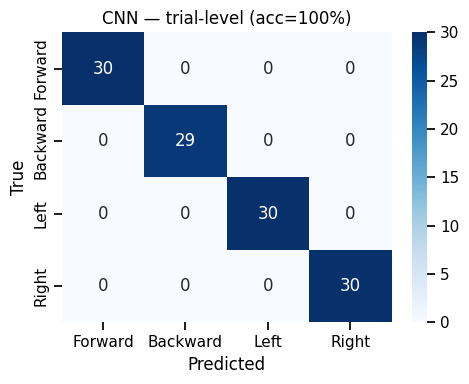

  CNN+BiLSTM                     100.0%   (119/119 trials)  [window-test 0.682]


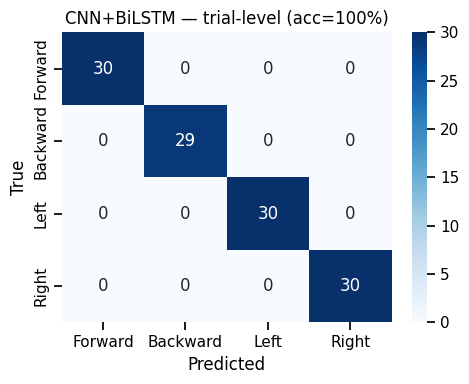

  CNN+BiLSTM+Attention           100.0%   (119/119 trials)  [window-test 0.581]


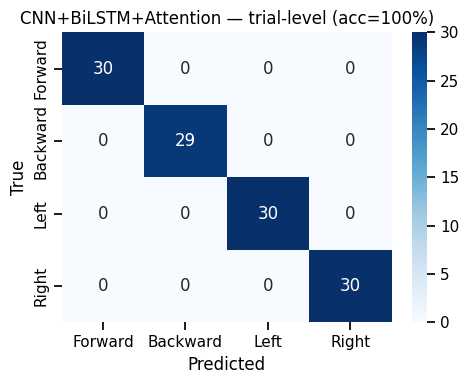

In [22]:
# ============================================================
# 16 · TRIAL-LEVEL TESTING — top-3 models × every 2560-row trial
#   Each file = N×2560-row TRIALS. Each trial block is preprocessed
#   exactly like training (bandpass+notch → 2 s windows → EA + z-score
#   on that block → 5-band), its windows aggregated → one prediction.
# ============================================================
TRIAL_LEN = 2560

def preprocess_block(eeg_block):                         # eeg_block: (18, 2560) raw
    eeg = bandpass_filter(eeg_block, CFG.FS, *CFG.BANDPASS)
    eeg = notch_filter(eeg, CFG.FS, CFG.NOTCH_FREQ, CFG.NOTCH_Q)
    eps = epoch_signal(eeg, CFG.EPOCH_LEN, CFG.EPOCH_STEP)
    if len(eps) == 0: return None
    eps = eps.astype(np.float32)
    if CFG.USE_EA: eps = euclidean_alignment(eps)
    eps = subject_zscore(eps).astype(np.float32)
    return decompose_bands(eps)                          # (n_win, 5, 18, 512)

@torch.no_grad()
def predict_block(model, Xb):
    model.eval(); x = torch.tensor(Xb, dtype=torch.float32); pr = []
    for i in range(0, len(x), CFG.BATCH_SIZE):
        pr.append(torch.softmax(model(x[i:i+CFG.BATCH_SIZE].to(DEVICE)), 1).cpu().numpy())
    p = np.concatenate(pr).mean(0); return int(p.argmax()), p

# ── build the test list: split every file into its 2560-row trial blocks ──
trials = []
for _, row in file_df.iterrows():
    eeg = load_raw(row.path)                              # (18, T_full)
    n = eeg.shape[1] // TRIAL_LEN
    for t in range(n):
        trials.append(dict(subject=row.subject, direction=row.direction, cue=row.cue,
                           trial=t+1, block=eeg[:, t*TRIAL_LEN:(t+1)*TRIAL_LEN]))
print(f'{len(trials)} trial-blocks of {TRIAL_LEN} rows to test '
      f'(across {file_df.shape[0]} files)')

# ── pick the TOP-3 models by test accuracy ──
top3 = sorted(ablation, key=lambda k: ablation[k]['accuracy'], reverse=True)[:3]
print('Top-3 models:', [(n, round(ablation[n]['accuracy'], 3)) for n in top3])

# ── fallback: if the ablation cell didn't store the models, retrain the top-3 ──
if 'trained_models' not in globals() or any(n not in trained_models for n in top3):
    print('\n(trained_models missing → retraining the top-3; add the 2-line edit to skip this)')
    LMAP = {nm: (flags, use_syn) for nm, flags, use_syn in LADDER}
    trained_models = globals().get('trained_models', {})
    for name in top3:
        flags, use_syn = LMAP[name]
        Xt, yt_ = (Xtr_aug, ytr_aug) if use_syn else (Xtr, ytr)
        trc, vac, _ = make_loaders(Xt, yt_, Xva, yva, Xte, yte)
        mm = build_model(**flags); mm, _ = train_model(mm, trc, vac, name=name, verbose=False)
        if use_syn and CFG.SYNTH_FINETUNE:
            trR = make_loaders(Xtr, ytr, Xva, yva, Xte, yte)[0]
            mm, _ = train_model(mm, trR, vac, name=name+'(ft)',
                                epochs=CFG.FINETUNE_EPOCHS, lr=CFG.LR*0.1, verbose=False)
        trained_models[name] = mm

# ── run the FULL trial list on each of the top-3 models ──
results = []
for name in top3:
    model = trained_models[name]
    for tr in trials:
        Xb = preprocess_block(tr['block'])
        if Xb is None: continue
        pred, probs = predict_block(model, Xb)
        results.append(dict(model=name, subject=tr['subject'], direction=tr['direction'],
                            cue=tr['cue'], trial=tr['trial'], pred=CFG.DIRECTIONS[pred],
                            conf=round(float(probs[pred]), 3),
                            correct=int(CFG.DIRECTIONS[pred] == tr['direction'])))
res_df = pd.DataFrame(results)
res_df.to_csv(CFG.OUT_DIR/'trial_test_results.csv', index=False)
display(res_df)                                          # ← the whole list, ×3 models

# ── per-model summary + confusion matrix ──
print('\n================  TRIAL-LEVEL ACCURACY  ================')
for name in top3:
    sub = res_df[res_df.model == name]
    acc = sub.correct.mean()
    print(f"  {name:30s} {acc:6.1%}   ({sub.correct.sum()}/{len(sub)} trials)  "
          f"[window-test {ablation[name]['accuracy']:.3f}]")
    cm = confusion_matrix([DIR_LABEL[d] for d in sub.direction],
                          [DIR_LABEL[p] for p in sub.pred], labels=range(CFG.N_CLASSES))
    plot_confusion(cm, f'{name} — trial-level (acc={acc:.0%})',
                   CFG.OUT_DIR/f"cm_trial_{name.replace('+','_')}.png")
